In [1]:
"""Smoke-test for the Rossmann store sales forecasting pipeline.

Generates a small synthetic dataset with a strong, easy-to-fit weekly pattern,
runs the full feature-engineering → nested CV pipeline, prints test-set metrics,
and plots real vs predicted sales for the last outer fold.

Usage: conda run -n rossmann python test_pipeline.py
"""

import os
import logging
import warnings

import optuna
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import src.constants as C

from matplotlib import cm
from src import features
from src.preprocessing import drop_null_targets
from src.engine.cv import TimeSeriesCV
from src.engine.metrics import compute_metrics
from src.engine import utils, hypertuning

from src import synthetic

FORECAST_HORIZON = 5

os.makedirs(C.LOG_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, 
                    filename=os.path.join(C.LOG_DIR, "test_pipeline.log"),
                    format="%(levelname)s  %(message)s")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

logger = logging.getLogger(__name__)



from pandas.tseries.offsets import DateOffset


def split_Xy(df, forecast_horizon):
    """Split a dataframe into features X and targets y.

    Closed-day sales (zeros) are first replaced by interpolated values so that
    lag/rolling features can be computed across those days.  The Sales column is
    then differenced with a lag of ``forecast_horizon``, so each target value is:

        y[t] = interpolated_sales[t + forecast_horizon] - interpolated_sales[t]

    i.e. the ``forecast_horizon``-step-ahead *change* in (interpolated) sales.

    Features are then generated from the differenced sales using the same lags,
    rolling windows, and differences plus store-related features.
    """

    sales_interp = utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
    df['Sales'] = sales_interp.groupby(level='Store').diff(periods=forecast_horizon)

    X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)
    y = make_targets(df['Sales'], forecast_horizon)
    X, y = drop_null_targets(X, y)
    
    return X, y



c:\Users\m_kal\Downloads\rossmann_store_sales\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Synthetic Data

Strong deterministic weekly + trend signal so the model can overfit easily and produce low errors.

 DayOfWeek  Open  Promo StateHoliday  SchoolHoliday      Sales StoreType Assortment  CompetitionDistance CompetitionSinceDate Promo2SinceDate   PromoInterval  Promo2  isStateHoliday  isSchoolHoliday CompetitionStartDate
         2     1      0    NoHoliday              0 467.320508         a          a                500.0           2012-04-01      2012-07-01 Jan,Apr,Jul,Oct       1           False            False           2012-04-01
         3     1      0            a              0 467.820508         a          a                500.0           2012-04-01      2012-07-01 Jan,Apr,Jul,Oct       1            True            False           2012-04-01
         4     1      0    NoHoliday              1 451.000000         a          a                500.0           2012-04-01      2012-07-01 Jan,Apr,Jul,Oct       1           False             True           2012-04-01
         5     1      0    NoHoliday              0 434.179492         a          a                500.0           2012-

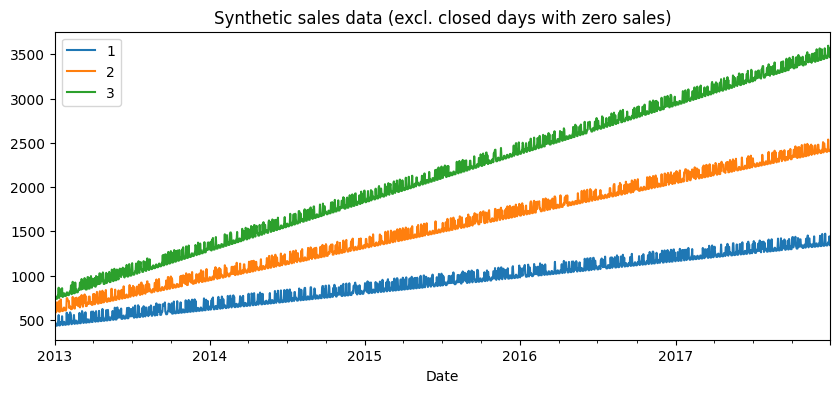

In [2]:
NUM_STORES = 3
NUM_DAYS = 365 * 5

stores = synthetic.store_data(n_stores=NUM_STORES)
sales = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)
df = sales.merge(stores, on='Store', how='left').set_index(['Store', 'Date']).sort_index(ascending=True)  # Ensure chronological order (NOT NEEDED FOR THE FEATURES WE'LL GENERATE, BUT GOOD PRACTICE IN GENERAL)

no_state_holiday = df['StateHoliday'].isin(['0', 0]) | df['StateHoliday'].isna()
df.loc[no_state_holiday, 'StateHoliday'] = 'NoHoliday'
df['isStateHoliday'] = df['StateHoliday'] != 'NoHoliday'
df['isSchoolHoliday'] = df['SchoolHoliday'].astype(bool)

df['CompetitionStartDate'] = df['CompetitionSinceDate'].apply(lambda x: pd.to_datetime(x) if pd.notnull(x) else pd.NaT)

df.loc[df['Sales'] == 0, 'Sales'] = np.nan
df.ffill(inplace=True)  # Fill NaN values with the last valid observation



cv_config = {
    "n_outer_splits":   C.N_OUTER_SPLITS,
    "n_inner_splits":   C.N_INNER_SPLITS,
    "forecast_horizon": FORECAST_HORIZON, #C.FORECAST_HORIZON,
    "inner_train_size": 1000, #C.INNER_TRAIN_SIZE,
}

cv_config["outer_train_size"] = (cv_config["n_inner_splits"] + 1) * cv_config["forecast_horizon"] + cv_config["inner_train_size"]


study_config = {
    "storage_url":           C.STORAGE_URL,
    "n_trials":              C.NUM_TRIALS,
    "n_startup_trials":      C.NUM_STARTUP_TRIALS,
    "n_jobs":                C.NUM_JOBS,
    "seed":                  C.SEED,
    "xgb_constants":         C.XGB_CONSTANTS,
    "early_stopping_rounds": C.EARLY_STOPPING_ROUNDS,
    "num_boost_rounds":      C.NUM_BOOST_ROUNDS,
    "monitor_periods":       C.MONITOR_PERIODS,
    "hyperparameters":       C.HYPERPARAMETERS,
    "log_dir":               C.LOG_DIR,
}

print(df.head(5).to_string(index=False))

(
    df
    .loc[df['Sales'] > 0]
    .reset_index()
    .set_index("Date")
    .groupby("Store")["Sales"]
    .plot(figsize=(10, 4),
          title="Synthetic sales data (excl. closed days with zero sales)",
          legend=True)
)

plt.savefig(os.path.join(C.LOG_DIR, "training_set.png"))

In [3]:
""" 
# Preprocessing steps:
# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, 
#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)
# 2. First-order differencing on the Sales column to make the series more stationary
# 3. Create features and targets for the whole dataset
# 4. Drop rows with null targets (i.e. those that don't have enough history
#    to create all requested lags, rolls, diffs, and/or forecast horizon)

df_processed = df.copy()
df_processed['Sales'] = (
    utils.overwrite_closed_sales(df_processed['Sales'], mode='interpolate')
    .groupby(level='Store')
    .diff()
)
X = make_features(df_processed, lags, rolling_windows, diffs)
y = make_targets(df_processed['Sales'], FORECAST_HORIZON)
X, y = drop_null_targets(X, y)

cv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],
                  horizon=cv_config["forecast_horizon"],
                  train_size=cv_config["outer_train_size"])

for fold, (train_ix, test_ix) in enumerate(cv.split(X, y), start=1):
    logger.info(f"Outer fold {fold}/{cv_config['n_outer_splits']} starting...")

    study_name = f"fold_{fold}"
    X_train, y_train = X.iloc[train_ix], y.iloc[train_ix]
    X_test, y_test = X.iloc[test_ix], y.iloc[test_ix]
    
    # Run Optuna hyperparameter tuning with nested CV in the inner loop
    logger.info(f"Running hyperparameter tuning ({study_config['n_trials']} trials)...")
    hypertuning.optimize(study_name, X_train, y_train, {**cv_config, **study_config})

    # Retrain final model on the entire outer fold training set with the best hyperparameters
    logger.info(f"Retraining model with the best hyperparameters...")
    study = optuna.load_study(study_name=study_name, storage=study_config["storage_url"])
    booster = hypertuning.refit(X_train, y_train, study.best_trial, study_config)
    
    logger.info(f"Evaluating final model on outer fold {fold} test set...")
    preds = utils.predict(booster, X_test)

    # Inverse first-order differencing to get predictions back on the original scale
    origin_index = preds.index.droplevel('Forecast Date')
    anchors = (utils.overwrite_closed_sales(df['Sales'], mode='interpolate')
               .loc[origin_index]
               .set_axis(preds.index))
    preds = anchors + preds.groupby(level=['Date', 'Store']).cumsum()
    
    # Log metrics and artifacts
    actuals = utils.retrieve_sales(df['Sales'], preds.index)
    metrics = compute_metrics(actuals.values, preds.values)
    logger.info(f"Test set metrics for fold {fold}: {metrics}")
    
    booster_file = os.path.join(study_config["log_dir"], study_name, "model.ubj")
    preds_file = os.path.join(study_config["log_dir"], study_name, "predictions.csv")
    booster.save_model(booster_file)
    preds.to_csv(preds_file)

    break
"""

' \n# Preprocessing steps:\n# 1. Overwrite zero sales for Sundays (closed) with interpolated values based on adjacent open days, \n#    to allow feature creation for those days (e.g. lags, rolls, diffs, forecast horizon)\n# 2. First-order differencing on the Sales column to make the series more stationary\n# 3. Create features and targets for the whole dataset\n# 4. Drop rows with null targets (i.e. those that don\'t have enough history\n#    to create all requested lags, rolls, diffs, and/or forecast horizon)\n\ndf_processed = df.copy()\ndf_processed[\'Sales\'] = (\n    utils.overwrite_closed_sales(df_processed[\'Sales\'], mode=\'interpolate\')\n    .groupby(level=\'Store\')\n    .diff()\n)\nX = make_features(df_processed, lags, rolling_windows, diffs)\ny = make_targets(df_processed[\'Sales\'], FORECAST_HORIZON)\nX, y = drop_null_targets(X, y)\n\ncv = TimeSeriesCV(n_splits=cv_config["n_outer_splits"],\n                  horizon=cv_config["forecast_horizon"],\n                  train_s

In [4]:
import xgboost as xgb
from src.engine import utils
from src.features.timeseries import lag_features
from src.engine.hypertuning import _objective
from optuna.trial import FixedTrial

FORECAST_HORIZON = 10
NUM_STORES = 4
NUM_DAYS = 365*4





stores = synthetic.store_data(n_stores=NUM_STORES)
sales = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)
df = sales.merge(stores, on='Store', how='left')
df = df.sample(frac=1, random_state=42)  # Shuffle the data

no_state_holiday = df['StateHoliday'].isin(['0', 0]) | df['StateHoliday'].isna()
df.loc[no_state_holiday, 'StateHoliday'] = 'NoHoliday'
df['isStateHoliday'] = df['StateHoliday'] != 'NoHoliday'
df['isSchoolHoliday'] = df['SchoolHoliday'].astype(bool)

df['CompetitionStartDate'] = df['CompetitionSinceDate'].apply(lambda x: pd.to_datetime(x) if pd.notnull(x) else pd.NaT)

df.loc[df['Sales'] == 0, 'Sales'] = np.nan
df.ffill(inplace=True)  # Fill NaN values with the last valid observation
grouped = (df
           .set_index(['Date'])
           .groupby('Store'))


lags = [pd.DateOffset(days=i) for i in range(1, 3)]
diffs = [pd.DateOffset(days=i) for i in range(1, 3)]
windows = ['7D', '14D', '30D']
forecast_steps = [pd.DateOffset(days=-i) for i in range(1, FORECAST_HORIZON+1)]
horizon = pd.DateOffset(days=FORECAST_HORIZON) # We use this to shift the features by the forecast
                                                   # horizon to align them with the target variable.
    
X = (grouped
     .apply(lambda df: features.compute(df, lags, diffs, windows, horizon)))

y = grouped['Sales'].apply(lag_features, forecast_steps)


"""
X, y = split_Xy(df.copy(), FORECAST_HORIZON)

inner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,
                        train_size=C.INNER_TRAIN_SIZE,
                        test_size=C.INNER_TEST_SIZE)

params = {
'max_depth': 6,
'learning_rate': 1e-3,
'subsample': 0.3,
'colsample_bytree': 0.3,
'min_child_weight': 1,
'reg_alpha': 0.1,
'reg_lambda': 0.1,
'gamma': 0.1,
}

mock_trial = FixedTrial(params)
obj_fcn = lambda trial: _objective(trial, X, y, inner_cv,
                                study_name='stuff',
                                study_config=study_config)

obj_fcn(mock_trial)
"""

"\nX, y = split_Xy(df.copy(), FORECAST_HORIZON)\n\ninner_cv = TimeSeriesCV(n_splits=C.N_INNER_SPLITS,\n                        train_size=C.INNER_TRAIN_SIZE,\n                        test_size=C.INNER_TEST_SIZE)\n\nparams = {\n'max_depth': 6,\n'learning_rate': 1e-3,\n'subsample': 0.3,\n'colsample_bytree': 0.3,\n'min_child_weight': 1,\n'reg_alpha': 0.1,\n'reg_lambda': 0.1,\n'gamma': 0.1,\n}\n\nmock_trial = FixedTrial(params)\nobj_fcn = lambda trial: _objective(trial, X, y, inner_cv,\n                                study_name='stuff',\n                                study_config=study_config)\n\nobj_fcn(mock_trial)\n"

In [7]:
df[['Date', 'Sales']].sort_index().head(10)

,Date,Sales
0,2013-01-01,467.320508
1,2013-01-02,467.820508
2,2013-01-03,451.000000
3,2013-01-04,434.179492
4,2013-01-05,434.679492
5,2013-01-06,2707.679492
6,2013-01-07,453.000000
7,2013-01-08,470.820508
8,2013-01-09,471.320508
9,2013-01-10,554.500000


In [11]:
X.sort_index().head(10)

lag_days_1   lag_days_2  diff_days_1  diff_days_2  \
Store Date                                                             
1     2013-01-01          NaN          NaN          NaN          NaN   
      2013-01-02   467.320508          NaN          NaN          NaN   
      2013-01-03   467.820508   467.320508     0.500000          NaN   
      2013-01-04   451.000000   467.820508   -16.820508   -16.320508   
      2013-01-05   434.179492   451.000000   -16.820508   -33.641016   
      2013-01-06   434.679492   434.179492     0.500000   -16.320508   
      2013-01-07  2707.679492   434.679492  2273.000000  2273.500000   
      2013-01-08   453.000000  2707.679492 -2254.679492    18.320508   
      2013-01-09   470.820508   453.000000    17.820508 -2236.858984   
      2013-01-10   471.320508   470.820508     0.500000    18.320508   

                  rolling_mean_7D  rolling_mean_14D  rolling_mean_30D  year  \
Store Date                                                                    
1     2013-01-01              NaN               NaN               NaN  2013   
      2013-01-02       467.320508        467.320508        467.320508  2013   
      2013-01-03       467.570508        467.570508        467.570508  2013   
      2013-01-04       462.047005        462.047005        462.047005  2013   
      2013-01-05       455.080127        455.080127        455.080127  2013   
      2013-01-06       451.000000        451.000000        451.000000  2013   
      2013-01-07       827.113249        827.113249        827.113249  2013   
      2013-01-08       773.668499        773.668499        773.668499  2013   
      2013-01-09       774.168499        735.812500        735.812500  2013   
      2013-01-10       774.668499        706.424501        706.424501  2013   

                  quarter  month  ...  day_of_week  is_month_start  \
Store Date                        ...                                
1     2013-01-01        1      1  ...            4           False   
      2013-01-02        1      1  ...            5           False   
      2013-01-03        1      1  ...            6           False   
      2013-01-04        1      1  ...            0           False   
      2013-01-05        1      1  ...            1           False   
      2013-01-06        1      1  ...            2           False   
      2013-01-07        1      1  ...            3           False   
      2013-01-08        1      1  ...            4           False   
      2013-01-09        1      1  ...            5           False   
      2013-01-10        1      1  ...            6           False   

                  is_weekend  is_weekday  is_month_end  \
Store Date                                               
1     2013-01-01       False        True         False   
      2013-01-02        True       False         False   
      2013-01-03        True       False         False   
      2013-01-04       False        True         False   
      2013-01-05       False        True         False   
      2013-01-06       False        True         False   
      2013-01-07       False        True         False   
      2013-01-08       False        True         False   
      2013-01-09        True       False         False   
      2013-01-10        True       False         False   

                  CompetitionDaysSinceStart  DaysToNextHoliday  \
Store Date                                                       
1     2013-01-01                        285               18.0   
      2013-01-02                        286               17.0   
      2013-01-03                        287               16.0   
      2013-01-04                        288               15.0   
      2013-01-05                        289               14.0   
      2013-01-06                        290               13.0   
      2013-01-07                        291               12.0   
      2013-01-08                        292               11.0   
      2

In [12]:
y.sort_index().head(10)

lag_days_-1  lag_days_-2  lag_days_-3  lag_days_-4  \
Store Date                                                             
1     2013-01-01   467.820508   451.000000   434.179492   434.679492   
      2013-01-02   451.000000   434.179492   434.679492  2707.679492   
      2013-01-03   434.179492   434.679492  2707.679492   453.000000   
      2013-01-04   434.679492  2707.679492   453.000000   470.820508   
      2013-01-05  2707.679492   453.000000   470.820508   471.320508   
      2013-01-06   453.000000   470.820508   471.320508   554.500000   
      2013-01-07   470.820508   471.320508   554.500000   437.679492   
      2013-01-08   471.320508   554.500000   437.679492   438.179492   
      2013-01-09   554.500000   437.679492   438.179492  2354.000000   
      2013-01-10   437.679492   438.179492  2354.000000   456.500000   

                  lag_days_-5  lag_days_-6  lag_days_-7  lag_days_-8  \
Store Date                                                             
1     2013-01-01  2707.679492   453.000000   470.820508   471.320508   
      2013-01-02   453.000000   470.820508   471.320508   554.500000   
      2013-01-03   470.820508   471.320508   554.500000   437.679492   
      2013-01-04   471.320508   554.500000   437.679492   438.179492   
      2013-01-05   554.500000   437.679492   438.179492  2354.000000   
      2013-01-06   437.679492   438.179492  2354.000000   456.500000   
      2013-01-07   438.179492  2354.000000   456.500000   474.320508   
      2013-01-08  2354.000000   456.500000   474.320508   474.820508   
      2013-01-09   456.500000   474.320508   474.820508   458.000000   
      2013-01-10   474.320508   474.820508   458.000000   541.179492   

                  lag_days_-9  lag_days_-10  
Store Date                                   
1     2013-01-01   554.500000    437.679492  
      2013-01-02   437.679492    438.179492  
      2013-01-03   438.179492   2354.000000  
      2013-01-04  2354.000000    456.500000  
      2013-01-05   456.500000    474.320508  
      2013-01-06   474.320508    474.820508  
      2013-01-07   474.820508    458.000000  
      2013-01-08   458.000000    541.179492  
      2013-01-09   541.179492    441.679492  
      2013-01-10   441.679492   1855.000000

In [13]:
booster = hypertuning.refit(X, y, mock_trial, study_config)

test_dmatrix  = xgb.DMatrix(X, enable_categorical=True)
diff_preds = booster.predict(test_dmatrix)
diff_preds = pd.Series(data=diff_preds, index=X.index)

# Inverse first-order differencing to get predictions back on the original scale
# diff_preds[t] = sales[t + FORECAST_HORIZON] - sales[t], so:
# preds[t] = diff_preds[t] + interpolated_sales[t]
anchors = utils.overwrite_closed_sales(df['Sales'].copy(), mode='interpolate').loc[diff_preds.index]
preds = anchors + diff_preds
preds = utils.overwrite_closed_sales(preds, mode='zero')

actuals = df.loc[preds.index, 'Sales']

In [14]:
max_date = actuals.index.get_level_values("Date").max()
min_date = max_date - pd.Timedelta(days=90)
actuals_recent = actuals.loc[(slice(min_date, max_date), slice(None))]
preds_recent = preds.loc[(slice(min_date, max_date), slice(None), slice(None))]

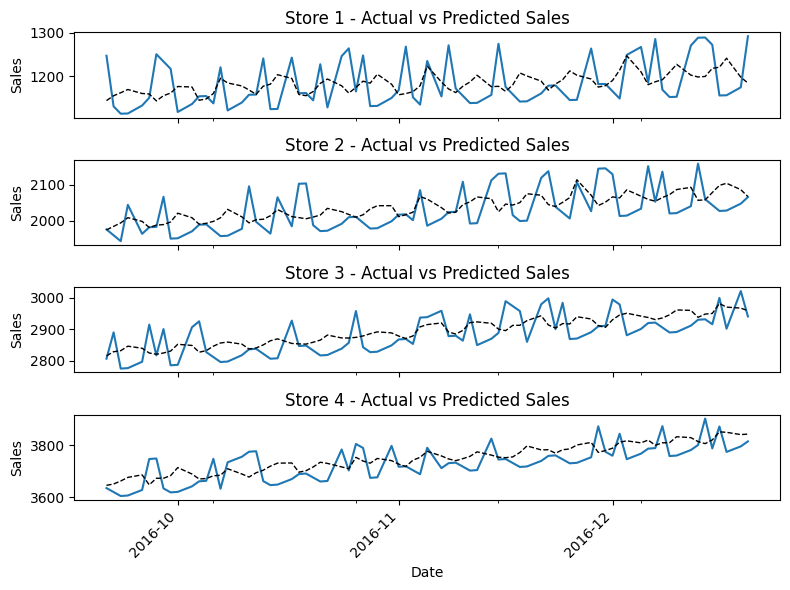

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


actuals = df.loc[preds.index, 'Sales']
actuals_small = actuals.iloc[:1200]
preds_small = preds.iloc[:1200]


stores = actuals_recent.index.get_level_values("Store").unique()
fig, ax = plt.subplots(figsize=(8, 6), nrows=len(stores), sharex=True, sharey=False)

for i, store in enumerate(stores):

    actual_store_sales = (actuals_recent
                        .loc[(slice(None), store)]
                        .sort_index())
    
    predicted_store_sales = (preds_recent
                            .loc[(slice(None), store, slice(None))]
                            .reset_index())

    # exclude closed days with zero sales and zero predictions
    actual_store_sales = actual_store_sales[actual_store_sales > 0]
    predicted_store_sales = predicted_store_sales[predicted_store_sales[0] > 0]

    actual_store_sales.plot(label=f"Store {store}", ax=ax[i])
    (predicted_store_sales
    #.groupby("Date")
    .plot(x="Date", y=0, ax=ax[i], color='k', linestyle='--', linewidth=1))

    ax[i].get_legend().remove()
    ax[i].set_title(f"Store {store} - Actual vs Predicted Sales")
    ax[i].set_ylabel("Sales")
    
# Rotate x labels and set date format
ax[-1].xaxis.set_major_locator(mdates.MonthLocator())
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
ax[-1].set_xlabel("Date")
plt.tight_layout()

In [16]:
stores = synthetic.store_data(n_stores=NUM_STORES)
train = synthetic.sales_data(n_stores=NUM_STORES, days=NUM_DAYS)
df  = attach_store_data(train, stores)
df.sort_values(['Date', 'Store'], inplace=True)  # Sort by date and store (ascending -> from earliest to latest) for lag features
df.set_index(["Date", "Store"], inplace=True)
X = make_features(df, C.LAGS, C.ROLL_WINDOWS, C.DIFFS)

forecast_horizon = 10
y = make_targets(df['Sales'], forecast_horizon)

# sales for store 1
store1 = df.index.get_level_values("Store") == 1
df_sales = df.loc[store1, "Sales"]
df_sales.name = "original_sales"

# features for store 1
store1 = X.index.get_level_values("Store") == 1
top_cols = [c for c in X.columns if 'lag' in c][:5]
x_sales = X.loc[store1, top_cols]
x_sales.columns = [f"feature_{col}" for col in x_sales.columns]

# targets for store 1
store1 = y.index.get_level_values("Store") == 1
ystore = y.loc[store1]
ystore.name = f"Target_horizon_{forecast_horizon}"

pd.concat([df_sales, x_sales, ystore], axis=1).head(30)

,,original_sales,feature_lag_1_days,feature_lag_2_days,feature_lag_3_days,feature_lag_4_days,feature_lag_5_days,Target_horizon_10
Date,Store,,,,,,,
2013-01-01,1,467.320508,NaN,NaN,NaN,NaN,NaN,437.679492
2013-01-02,1,467.820508,467.320508,NaN,NaN,NaN,NaN,438.179492
2013-01-03,1,451.000000,467.820508,467.320508,NaN,NaN,NaN,0.000000
2013-01-04,1,434.179492,451.000000,467.820508,467.320508,NaN,NaN,456.500000
2013-01-05,1,534.679492,434.179492,451.000000,467.820508,467.320508,NaN,474.320508
2013-01-06,1,0.000000,534.679492,434.179492,451.000000,467.820508,467.320508,574.820508
2013-01-07,1,453.000000,0.000000,534.679492,434.179492,451.000000,467.820508,458.000000
2013-01-08,1,470.820508,453.000000,0.000000,534.679492,434.179492,451.000000,541.179492
2013-01-09,1,571.320508,470.820508,453.000000,0.000000,534.679492,434.179492,441.679492


In [90]:
predicted_store_sales

,Date,Forecast Date,0
0,2016-09-27,2016-09-28,1226.649998
1,2016-09-28,2016-09-29,1226.371926
2,2016-09-29,2016-09-30,1111.006675
3,2016-09-30,2016-10-01,1089.886573
4,2016-10-01,2016-10-02,1088.029492
...,...,...,...
85,2016-12-21,2016-12-22,1141.493492
86,2016-12-22,2016-12-23,1123.633712
87,2016-12-23,2016-12-24,1100.427859
88,2016-12-24,2016-12-25,1100.629492
